# LEC: elapsed-time vs goal-progress — out-of-distribution dissociation

Companion to `LEC_glm_tuning_variables.ipynb`. The GLM there partitions
in-sample variance (CPD / nested-F); when elapsed time and goal progress are
collinear that cannot cleanly adjudicate. Here we use the decisive test: fit a
reference frame on **short** inter-reward legs and predict held-out **long** legs
(and the reverse). Whichever frame extrapolates across durations is the code.

Two contrasts: elapsed time vs **temporal phase** (t/D) and elapsed time vs
**spatial progress** (distance fraction). Plus a continuous warp
`c = t / D**alpha` (alpha=0 time, alpha=1 phase) and a Poisson cross-check.

All heavy lifting is in `time_vs_progress_dissociation.py`.

In [1]:
import sys
sys.path.insert(0, ".")
from importlib import reload
import numpy as np, pandas as pd, pickle, os
import matplotlib.pyplot as plt
import glm_analysis_v2, time_vs_progress_dissociation as tp
reload(glm_analysis_v2); reload(tp)
from glm_analysis_v2 import apply_gridmaze_style
apply_gridmaze_style()

In [2]:
# ── LEC data ────────────────────────────────────────────────────────
import os, pickle, numpy as np
import glm_analysis_v2 as glm

Data_folder = "../data/processed_data"
neuron_folder = f"{Data_folder}/neuron_raw_mingyutest"

# load_data_dic drops known-bad recdays and asserts that each recday's unit count
# and task sequences come from the recording day it is named after -- see
# code/recday_registry.py and docs/BUG_ly05_recday_mismatch.md. A bare
# pickle.load cannot catch a recday paired to the wrong day's sorting.
data_dic = glm.load_data_dic(os.path.join(Data_folder, "data_dic_lec.pkl"))

# recday list from the Neuron_raw_* filenames (mouse_recday = name minus session)
neuron_files = [f for f in os.listdir(neuron_folder)
                if f.startswith("Neuron_raw_") and f.endswith(".npy")]
recdays = sorted({"_".join(f[len("Neuron_raw_"):-len(".npy")].split("_")[:-1])
                  for f in neuron_files})
mouse_recdays = [mr for mr in recdays if mr in data_dic]
REGION = "LEC"
SAVE_DIR = "../glm_outputs/LEC_time_vs_progress"
print(f"{len(mouse_recdays)} LEC recdays")

24 LEC recdays


## 1. Build the long-format design tables

One pooled table per recday: per-sample elapsed time `t`, leg duration `D`,
temporal phase `t/D`, spatial progress, distance, kinematics, node, and an
`interval_id` for leg-level CV / bootstrap splits. Correct-path + <=60 s
transition filter applied (matches the filtered GLM section). Cached to disk.

In [3]:
os.makedirs(SAVE_DIR, exist_ok=True)
TABLES_PKL = os.path.join(SAVE_DIR, "design_tables.pkl")
if os.path.exists(TABLES_PKL):
    with open(TABLES_PKL, "rb") as f: tables = pickle.load(f)
    print(f"loaded {len(tables)} cached tables")
else:
    # All legs within a 60 s duration bound are kept (filter_correct_paths=False):
    # the duration-split bootstrap needs as many legs as possible for power. Set
    # filter_correct_paths=True to restrict to shortest-path legs (fewer, cleaner).
    tables = tp.build_design_tables(
        mouse_recdays, data_dic,
        downsample_factor=10, filter_correct_paths=False, max_transition_seconds=60)
    with open(TABLES_PKL, "wb") as f: pickle.dump(tables, f, protocol=4)
n_neurons = sum(t["FR"].shape[0] for t in tables.values())
print(f"{len(tables)} recdays, {n_neurons} neurons total")

loaded 24 cached tables
24 recdays, 2742 neurons total


## 2. Synthetic positive control

Inject a known fixed-latency **time** cell and a fixed-**phase** cell into a real
recday's covariate structure, and confirm the OOD test and the warp recover them
(delta>0 / <0, alpha*≈0 / ≈1). This proves the test has resolving power on *this*
duration distribution before trusting it on real cells.

In [4]:
mr0 = list(tables)[0]
syn = tp.append_synthetic_neurons(tables[mr0], peak_t=3.0, phi_star=0.6)
N = syn["FR"].shape[0]
ood_syn = tp.run_ood_gaussian(syn, "temporal", n_boot=200)
al_syn  = tp.run_alpha_gaussian(syn)
print("planted TIME  cell (row -2):",
      f"delta={ood_syn.delta_ood.iloc[-2]:+.3f}  alpha*={al_syn.alpha_star.iloc[-2]:+.2f}")
print("planted PHASE cell (row -1):",
      f"delta={ood_syn.delta_ood.iloc[-1]:+.3f}  alpha*={al_syn.alpha_star.iloc[-1]:+.2f}")
assert ood_syn.delta_ood.iloc[-2] > 0 and ood_syn.delta_ood.iloc[-1] < 0, "OOD failed to recover controls"
print("positive control PASSED")

planted TIME  cell (row -2): delta=+0.901  alpha*=+0.10
planted PHASE cell (row -1): delta=-0.773  alpha*=+1.00
positive control PASSED


## 3. Contrast 1 — elapsed time vs temporal phase (t/D)

Per-neuron held-out pseudo-R² for each frame under the short<->long split.
`delta_ood = R2_abs - R2_phase`: **>0 favours elapsed time, <0 favours phase**.

The **region-level answer** is the sign/median of the pooled `delta_ood`
distribution (`population_delta_test`) — per-cell classification needs a
bootstrap CI to exclude 0, which is deliberately strict, so on limited data most
individual cells read "ambiguous" while the population still leans clearly one
way.

OOD temporal/gaussian:   0%|          | 0/24 [00:00<?, ?it/s]

OOD temporal/gaussian: 100%|██████████| 24/24 [14:00<00:00, 35.00s/it]


region    n  median_delta  mean_delta  frac_leaning_time   wilcoxon_p
   LEC 2742      -0.00045   -0.002958           0.474106 4.919663e-09
class
ambiguous         2442
time               170
temporal_phase     130
Name: count, dtype: int64


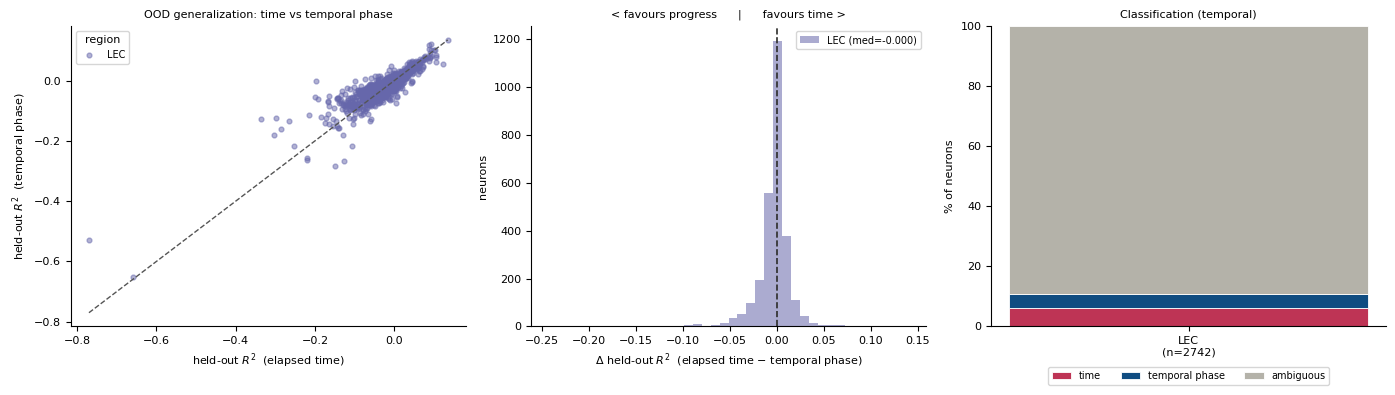

In [5]:
ood_t = tp.run_population_ood(tables, "temporal", family="gaussian", region=REGION, n_boot=200)
ood_t = tp.classify(ood_t, r2_floor=0.01)
# HEADLINE: sign of the pooled delta distribution (median<0 -> region leans
# phase; >0 -> leans elapsed time). Robust to the conservative per-cell CI.
print(tp.population_delta_test(ood_t).to_string(index=False))
print(ood_t["class"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
tp.plot_ood_scatter(ood_t, "temporal", ax=axes[0])
tp.plot_delta_hist(ood_t, "temporal", ax=axes[1])
tp.plot_classification(ood_t, "temporal", ax=axes[2])
plt.tight_layout(); plt.show()

## 4. Contrast 2 — elapsed time vs spatial progress (distance fraction)

OOD spatial/gaussian: 100%|██████████| 24/24 [14:47<00:00, 36.98s/it]


region    n  median_delta  mean_delta  frac_leaning_time    wilcoxon_p
   LEC 2742     -0.003199   -0.007864           0.286652 2.768225e-151
class
ambiguous           2355
spatial_progress     245
time                 142
Name: count, dtype: int64


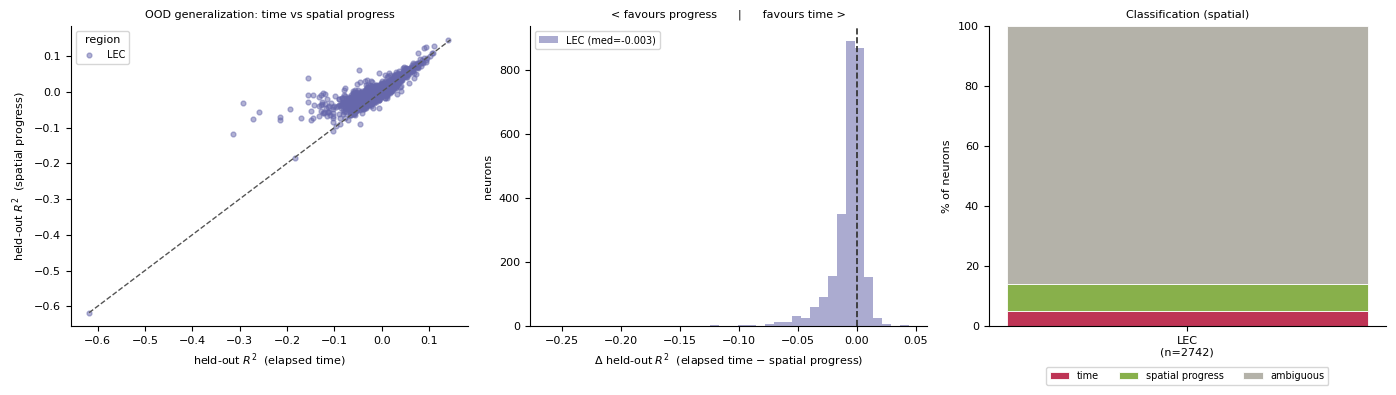

In [6]:
ood_s = tp.run_population_ood(tables, "spatial", family="gaussian", region=REGION, n_boot=200)
ood_s = tp.classify(ood_s, r2_floor=0.01)
print(tp.population_delta_test(ood_s).to_string(index=False))
print(ood_s["class"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
tp.plot_ood_scatter(ood_s, "spatial", ax=axes[0])
tp.plot_delta_hist(ood_s, "spatial", ax=axes[1])
tp.plot_classification(ood_s, "spatial", ax=axes[2])
plt.tight_layout(); plt.show()

## 5. Continuous warp alpha (time <-> temporal phase)

`c = t / D**alpha`. Per-neuron `alpha*` from cross-validated held-out fit; a tight
CI near 0 is a genuine time cell, near 1 a genuine phase cell. The population
histogram + Hartigan dip test says dichotomy vs continuum.

alpha warp: 100%|██████████| 24/24 [5:10:03<00:00, 775.15s/it]  


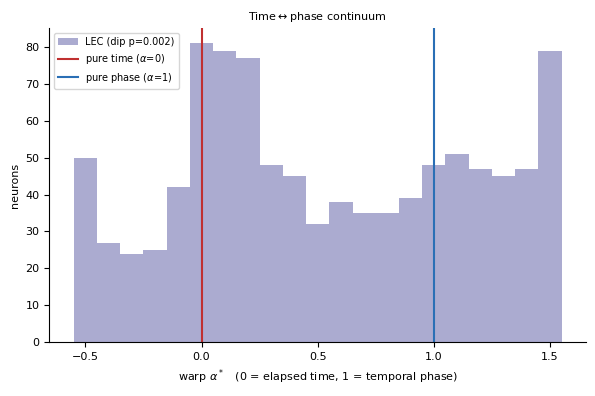

994 tuned cells; median alpha* = +0.40


In [7]:
alpha_df = tp.run_population_alpha(tables, region=REGION)
# restrict to cells with real temporal/phase structure for the population view
tuned = alpha_df["r2_at_star"] > 0.01
fig, ax = plt.subplots(figsize=(6, 4))
tp.plot_alpha_hist(alpha_df[tuned], ax=ax)
plt.tight_layout(); plt.show()
print(f"{tuned.sum()} tuned cells; median alpha* = {alpha_df.loc[tuned,'alpha_star'].median():+.2f}")

## 6. Poisson cross-check (headline contrast)

Re-run contrast 1 with a Poisson likelihood (log link). The *sign* of delta
should agree with Gaussian for the large majority. Run on a subset of recdays
for speed (IRLS loops neurons).

OOD temporal/poisson: 100%|██████████| 24/24 [19:45:08<00:00, 2962.85s/it]   


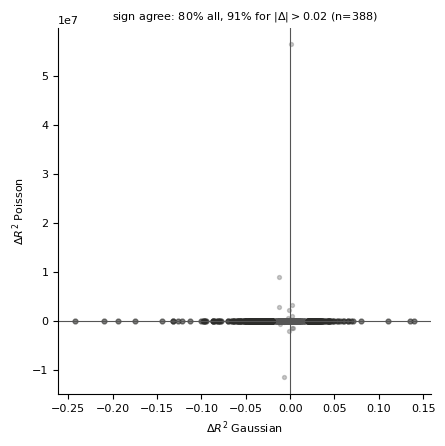

In [9]:
subset = {mr: tables[mr] for mr in list(tables)[:]}
ood_t_p = tp.run_population_ood(subset, "temporal", family="poisson", region=REGION)
ood_t_g = ood_t[ood_t["recday"].isin(subset)]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
tp.plot_gaussian_vs_poisson(ood_t_g, ood_t_p, ax=ax)
plt.tight_layout(); plt.show()

## 7. Tuning gate + interpretable peak-latency figure

Optional circular-shift null gating "is there any temporal/phase structure"
(slow — one recday shown). Then the interpretable figure: model-derived peak
latency vs leg duration for an example time-classified cell (flat = time cell,
slope ∝ D = phase cell). Latency is read off the fitted curve, never argmax.

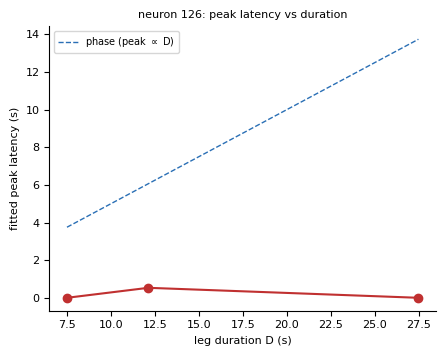

In [8]:
# example: strongest time-classified cell in the first recday
ex = ood_t[(ood_t["recday"] == mr0) & (ood_t["class"] == "time")].sort_values("delta_ood")
if len(ex):
    nrn = int(ex.iloc[-1]["neuron"])
    fig, ax = plt.subplots(figsize=(4.5, 3.6))
    tp.plot_peak_latency_vs_duration(tables[mr0], nrn, ax=ax)
    plt.tight_layout(); plt.show()
else:
    print("no time-classified cell in", mr0)

## 8. Save results

In [ ]:
for name, df in [("ood_temporal", ood_t), ("ood_spatial", ood_s), ("alpha", alpha_df)]:
    df.to_pickle(os.path.join(SAVE_DIR, f"{name}.pkl"))
print("saved to", SAVE_DIR)